# Dataloader + Training Loop
### NYU Depth V2 → MonocularSAMModel (DA V2 ViT-S + SAM-B Fusion)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2
import h5py
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import os

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, 'D:/Projects/Minor Project/Models')  # folder where blocks.py lives

from blocks import (
    get_depth_encoder_features,
    DepthAnythingProjection,
    PositionalEmbeddings,
    TransformerBlock,
    DepthDecoder,
    DepthSAMFusion,
    get_point_prompt_from_mask,
    MonocularSAMModel
)

import inspect
print(inspect.getsource(get_point_prompt_from_mask))

def get_point_prompt_from_mask(gt_mask_np, mask_size=256, sam_size=1024):
    ys, xs = np.where(gt_mask_np > 0)
    if len(xs) == 0:
        cx, cy = sam_size // 2, sam_size // 2
    else:
        scale = sam_size / mask_size          # 1024/256 = 4.0
        cx = int(xs.mean() * scale)           # scale to SAM space
        cy = int(ys.mean() * scale)

    point_coords = torch.tensor([[[cx, cy]]], dtype=torch.float32)
    point_labels = torch.tensor([[1]], dtype=torch.int)
    return point_coords, point_labels



## initializing depth model

In [3]:
sys.path.insert(0, 'D:/Projects/Minor Project/Depth-Anything-V2/metric_depth')

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

from depth_anything_v2.dpt import DepthAnythingV2

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

encoder = 'vits' # or 'vits', 'vitb'
dataset = 'hypersim' # 'hypersim' for indoor model, 'vkitti' for outdoor model
max_depth = 10 # 20 for indoor model, 80 for outdoor model

check_path = f'D:/Projects/Minor Project/Parameters/DA-Parameter/depth_anything_v2_metric_hypersim_{encoder}.pth'

model = DepthAnythingV2(**model_configs[encoder], max_depth=max_depth)
model.load_state_dict(torch.load(check_path, map_location='cpu'))
model = model.to(DEVICE).eval()
print(DEVICE)

A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "d:\Projects\Minor Project\.venv\lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
ModuleNotFoundError: No module named 'triton'


cuda


## 1. Dataset

In [ ]:
class NYUDepthV2Dataset(Dataset):
    def __init__(self, mat_path, split='train', train_ratio=0.8,
                 depth_cache=None, sam_cache=None):
        self.mat_path    = mat_path
        self.depth_cache = depth_cache
        self.sam_cache   = sam_cache
        self.split       = split

        with h5py.File(mat_path, 'r') as f:
            total     = f['images'].shape[0]
            split_idx = int(total * train_ratio)
            self.indices = list(range(0, split_idx)) if split == 'train' \
                      else list(range(split_idx, total))
            self.images = np.array(f['images'][self.indices])
            self.depths = np.array(f['depths'][self.indices])
            self.labels = np.array(f['labels'][self.indices])

        # ── Fix val classes so IoU is comparable across epochs ──
        self.fixed_classes = []
        for i in range(len(self.indices)):
            lbl = np.transpose(self.labels[i], (1, 0))
            u, c = np.unique(lbl, return_counts=True)
            mask = u > 0
            u, c = u[mask], c[mask]
            self.fixed_classes.append(u[np.argmax(c)]) 

        print(f"[{split}] {len(self.indices)} samples loaded")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]

        img   = np.transpose(self.images[idx], (2, 1, 0))   # (480, 640, 3)
        depth = np.transpose(self.depths[idx], (1, 0))      # (480, 640)
        label = np.transpose(self.labels[idx], (1, 0))      # (480, 640)

        # ── GT depth ──────────────────────────────────────────
        depth    = np.clip(depth.astype(np.float32), 0, 10.0)
        gt_depth = torch.from_numpy(depth).unsqueeze(0)     # [1, 480, 640]

        chosen_class = self.fixed_classes[idx]

        binary_mask = (label == chosen_class).astype(np.float32)
        mask_256    = cv2.resize(binary_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        gt_mask     = torch.from_numpy(mask_256).unsqueeze(0)  # [1, 256, 256]

        # ── Cached features ───────────────────────────────────
        depth_feat = self.depth_cache[real_idx] if self.depth_cache is not None else None
        sam_feat   = self.sam_cache[real_idx]   if self.sam_cache   is not None else None

        return {
            'sam_feat'   : sam_feat,     # [256, 64, 64]
            'depth_feat' : depth_feat,   # [384, 37, 37]
            'gt_mask'    : gt_mask,      # [1, 256, 256]
            'gt_depth'   : gt_depth,     # [1, 480, 640]
            'index'      : real_idx
        }

In [ ]:
def precompute_depth_features(depth_model, dataset, cache_path, device):
    if os.path.exists(cache_path):
        print(f"Loading cached depth features from {cache_path}")
        return torch.load(cache_path)

    print("Pre-computing depth features...")
    all_features = {}

    for idx in tqdm(dataset.indices):
        with h5py.File(dataset.mat_path, 'r') as f:
            img = np.transpose(np.array(f['images'][idx]), (2, 1, 0))
        raw_img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        features   = {}
        input_size = {}

        def hook(module, input, output):
            features['out'] = output

        handle = depth_model.pretrained.blocks[-1].register_forward_hook(hook)
        with torch.no_grad():
            image, _ = depth_model.image2tensor(raw_img_bgr, input_size=518)
            pH = image.shape[2] // 14
            pW = image.shape[3] // 14
            depth_model.forward(image.to(device))
        handle.remove()

        enc     = features['out'][:, 1:, :].cpu()
        B, N, C = enc.shape
        spatial = enc.reshape(B, pH, pW, C).permute(0, 3, 1, 2)
        spatial = F.interpolate(spatial, size=(37, 37), mode='bilinear', align_corners=False)
        all_features[idx] = spatial.squeeze(0)  # [384, 37, 37]

    torch.save(all_features, cache_path)
    print(f"Saved to {cache_path}")
    return all_features

In [ ]:
def precompute_sam_features(sam_model, dataset, cache_path, device):
    if os.path.exists(cache_path):
        print(f"Loading cached SAM features from {cache_path}")
        return torch.load(cache_path)

    print("Pre-computing SAM features (runs once)...")
    sam_model.eval()
    all_features = {}

    for local_idx, real_idx in enumerate(tqdm(dataset.indices)):
        img      = np.transpose(dataset.images[local_idx], (2, 1, 0))  # (480,640,3)
        img_1024 = cv2.resize(img, (1024, 1024), interpolation=cv2.INTER_LINEAR)
        sam_inp  = torch.from_numpy(img_1024).permute(2,0,1).float() / 255.0
        sam_inp  = sam_inp.unsqueeze(0).to(device)  # [1, 3, 1024, 1024]

        with torch.no_grad():
            feat = sam_model.image_encoder(sam_inp)  # [1, 256, 64, 64]

        all_features[real_idx] = feat.squeeze(0).cpu()  # [256, 64, 64]

    torch.save(all_features, cache_path)
    print(f"Saved to {cache_path}")
    return all_features

In [ ]:
MAT_PATH   = 'D:/Projects/Minor Project/Datasets/raw/NYU depth v2/nyu_depth_v2_labeled.mat'
BATCH_SIZE = 4

train_dataset = NYUDepthV2Dataset(MAT_PATH, split='train')  # no cache yet
val_dataset   = NYUDepthV2Dataset(MAT_PATH, split='val')    # no cache yet

In [ ]:
CACHE_DIR = 'D:/Projects/Minor Project/Parameters/Cache'
os.makedirs(CACHE_DIR, exist_ok=True)

train_depth_cache = precompute_depth_features(
    model, train_dataset,
    cache_path=f'{CACHE_DIR}/train_depth_features.pt',
    device=DEVICE
)
val_depth_cache = precompute_depth_features(
    model, val_dataset,
    cache_path=f'{CACHE_DIR}/val_depth_features.pt',
    device=DEVICE
)

In [ ]:

train_dataset = NYUDepthV2Dataset(MAT_PATH, split='train', depth_cache=train_depth_cache, sam_cache=train_sam_cache)
val_dataset   = NYUDepthV2Dataset(MAT_PATH, split='val',   depth_cache=val_depth_cache,   sam_cache=val_sam_cache)

def custom_collate(batch):
    return {
        'sam_feat'   : torch.stack([b['sam_feat']   for b in batch]),
        'depth_feat' : torch.stack([b['depth_feat'] for b in batch]),
        'gt_mask'    : torch.stack([b['gt_mask']    for b in batch]),
        'gt_depth'   : torch.stack([b['gt_depth']   for b in batch]),
        'index'      : [b['index'] for b in batch]
    }

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=custom_collate)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=custom_collate)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

In [ ]:
batch = next(iter(train_loader))
print(f"sam_feat:    {batch['sam_feat'].shape}   {batch['sam_feat'].dtype}")
print(f"depth_feat:  {batch['depth_feat'].shape} {batch['depth_feat'].dtype}")
print(f"gt_mask:     {batch['gt_mask'].shape}    {batch['gt_mask'].dtype}")
print(f"gt_depth:    {batch['gt_depth'].shape}   {batch['gt_depth'].dtype}")

## 2. Model Setup

In [4]:
from segment_anything import sam_model_registry

SAM_PATH  = 'D:/Projects/Minor Project/Parameters/SAM-Parameter/sam_vit_b_01ec64.pth'
sam_model = sam_model_registry['vit_b'](checkpoint=SAM_PATH)

depth_proj    = DepthAnythingProjection(in_channels=384, out_channels=256)
fusion_layer  = DepthSAMFusion()
depth_decoder = DepthDecoder(in_channels=256) 

fusion_model = MonocularSAMModel(
    sam_model            = sam_model,
    depth_anything_model = model,
    depth_proj           = depth_proj,
    fusion_layer         = fusion_layer,
    depth_decoder        = depth_decoder        # ← new
).to(DEVICE)

# Count trainable parameters
trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in fusion_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 11,300,850 / 123,028,338


In [10]:
# ── Instance Segmentation with NMS ────────────────────────────────────────
def mask_iou(mask_a, mask_b):
    inter = (mask_a & mask_b).sum()
    union = (mask_a | mask_b).sum()
    return inter / (union + 1e-6)


def get_instance_segmentation(fusion_model, img_np, device,
                               grid_size=12,
                               iou_threshold=0.88,
                               score_threshold=0.3,
                               min_coverage=0.005,
                               max_coverage=0.90):
    fusion_model.eval()
    H, W = img_np.shape[:2]

    # encode once
    img_bgr  = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    img_1024 = cv2.resize(img_np, (1024, 1024))
    sam_inp  = torch.from_numpy(img_1024).permute(2, 0, 1).float() / 255.0
    sam_inp  = sam_inp.unsqueeze(0).to(device)

    with torch.no_grad():
        sam_feat   = fusion_model.sam.image_encoder(sam_inp)
        depth_feat = get_depth_encoder_features(fusion_model.depth_model, img_bgr).to(device)
        _, _, pred_depth = fusion_model(sam_feat, depth_feat)

    depth_np = F.interpolate(pred_depth, size=(H, W), mode='bilinear', align_corners=False)\
                 .squeeze().cpu().numpy()

    # dense grid prompts
    pad = 20
    ys  = np.linspace(pad, H - pad, grid_size).astype(int)
    xs  = np.linspace(pad, W - pad, grid_size).astype(int)

    raw_masks, raw_scores = [], []
    for y in ys:
        for x in xs:
            pt_coords = torch.tensor([[[x, y]]], dtype=torch.float32).to(device)
            pt_labels = torch.tensor([[1]], dtype=torch.int).to(device)
            with torch.no_grad():
                low_res, iou_pred, _ = fusion_model(sam_feat, depth_feat, pt_coords, pt_labels)
            score = iou_pred.item()
            if score < score_threshold:
                continue
            mask = F.interpolate(
                (torch.sigmoid(low_res) > 0.3).float(),
                size=(H, W), mode='nearest'
            ).squeeze().cpu().numpy().astype(bool)
            coverage = mask.sum() / (H * W)
            if coverage < min_coverage or coverage > max_coverage:
                continue
            raw_masks.append(mask)
            raw_scores.append(score)

    if len(raw_masks) == 0:
        print("No masks passed threshold.")
        return np.zeros((H, W), dtype=np.int32), {}

    # NMS — sort by score, suppress overlapping masks
    order = np.argsort(raw_scores)[::-1]
    kept  = []
    for idx in order:
        if all(mask_iou(raw_masks[idx], raw_masks[k]) <= iou_threshold for k in kept):
            kept.append(idx)

    # build instance map
    instance_map    = np.zeros((H, W), dtype=np.int32)
    instance_depths = {}
    instance_scores = {}
    for iid, kidx in enumerate(kept, start=1):
        m = raw_masks[kidx]
        free = (instance_map == 0)
        instance_map[m & free] = iid
        instance_depths[iid]   = float(depth_np[m].mean())
        instance_scores[iid]   = raw_scores[kidx]

    n = len(kept)
    cmap    = plt.cm.get_cmap('tab20', max(n, 1))
    colored = np.zeros((H, W, 3), dtype=np.uint8)
    for iid in range(1, n + 1):
        colored[instance_map == iid] = (np.array(cmap(iid % 20)[:3]) * 255).astype(np.uint8)
    overlay = (img_np * 0.45 + colored * 0.55).astype(np.uint8)

    depth_vis = np.zeros((H, W))
    for iid, d in instance_depths.items():
        depth_vis[instance_map == iid] = d

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(img_np);    axes[0].set_title('RGB');             axes[0].axis('off')
    axes[1].imshow(overlay);   axes[1].set_title(f'Instances ({n})'); axes[1].axis('off')
    axes[2].imshow(depth_vis, cmap='plasma'); axes[2].set_title('Per-Instance Depth'); axes[2].axis('off')
    plt.colorbar(axes[2].images[0], ax=axes[2])
    axes[3].imshow(depth_np,  cmap='plasma'); axes[3].set_title('Full Depth');         axes[3].axis('off')
    plt.colorbar(axes[3].images[0], ax=axes[3])
    for ax in axes[1:3]:
        for iid in range(1, n + 1):
            ys_i, xs_i = np.where(instance_map == iid)
            if len(ys_i) == 0: continue
            ax.text(int(xs_i.mean()), int(ys_i.mean()), str(iid), color='white',
                    fontsize=9, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))
    plt.tight_layout(); plt.show()

    print(f"\n{n} instances (from {len(raw_masks)} candidates):")
    for iid in range(1, n + 1):
        print(f"  {iid:2d}: depth={instance_depths[iid]:.2f}m  score={instance_scores[iid]:.3f}  px={(instance_map==iid).sum()}")

    return instance_map, instance_depths

## 3. Loss Functions

In [7]:
def dice_loss(pred_logits, gt_mask, smooth=1.0):
    """
    Dice loss for segmentation.
    pred_logits: [B, 1, H, W] raw logits
    gt_mask:     [B, 1, H, W] binary float
    """
    pred  = torch.sigmoid(pred_logits)
    pred  = pred.view(pred.size(0), -1)
    gt    = gt_mask.view(gt_mask.size(0), -1)
    inter = (pred * gt).sum(dim=1)
    dice  = (2.0 * inter + smooth) / (pred.sum(dim=1) + gt.sum(dim=1) + smooth)
    return 1 - dice.mean()


def seg_loss(pred_logits, gt_mask):
    pos_weight = torch.tensor([5.0]).to(pred_logits.device)  # ← back but higher
    bce  = F.binary_cross_entropy_with_logits(pred_logits, gt_mask, pos_weight=pos_weight)
    dice = dice_loss(pred_logits, gt_mask)
    return bce + dice

def depth_loss(pred_depth, gt_depth):
    valid_mask = gt_depth > 0
    if valid_mask.sum() == 0:
        return torch.tensor(0.0, device=gt_depth.device)
    pred = torch.clamp(pred_depth[valid_mask], min=0.1)
    gt   = torch.clamp(gt_depth[valid_mask],   min=0.1)
    log_diff = torch.log(pred) - torch.log(gt)
    silog    = log_diff.pow(2).mean() - 0.5 * log_diff.mean().pow(2)
    return torch.clamp(silog, max=2.0)  # ← cap spikes

## 4. Training Loop

In [ ]:
def get_depth_features_batched(fusion_model, raw_imgs_np):
    """
    Run DA V2 encoder on a batch of numpy images.
    Returns: [B, 384, pH, pW] depth features on DEVICE
    """
    all_features = []

    for raw_img in raw_imgs_np:
        features   = {}
        input_size = {}

        def hook(module, input, output):
            features['out'] = output

        handle = fusion_model.depth_model.pretrained.blocks[-1].register_forward_hook(hook)

        with torch.no_grad():
            image, (h, w) = fusion_model.depth_model.image2tensor(raw_img, input_size=518)
            pH = image.shape[2] // 14
            pW = image.shape[3] // 14
            fusion_model.depth_model.forward(image.to(DEVICE))

        handle.remove()

        enc     = features['out'][:, 1:, :]                           # remove CLS
        B, N, C = enc.shape
        spatial = enc.reshape(B, pH, pW, C).permute(0, 3, 1, 2)      # [1, 384, pH, pW]

        # Resize to fixed size for batching
        spatial = F.interpolate(spatial, size=(37, 37), mode='bilinear', align_corners=False)
        all_features.append(spatial)

    return torch.cat(all_features, dim=0)   # [B, 384, 37, 37]


# ── Redefine train/val functions (fast version) ───────────────────────────────
def train_one_epoch(fusion_model, loader, optimizer, device):
    fusion_model.train()
    fusion_model.sam.image_encoder.eval()
    fusion_model.depth_model.eval()

    print(f"  VRAM: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")

    total_loss = total_seg = total_dep = 0.0
    loop = tqdm(loader, leave=True)
    max_grad = 0.0 
    
    for batch in loop:
        sam_feat   = batch['sam_feat'].to(device)
        depth_feat = batch['depth_feat'].to(device)
        gt_mask    = batch['gt_mask'].to(device)      # [B, 1, 256, 256]
        gt_depth   = batch['gt_depth'].to(device)

        optimizer.zero_grad()

        # ── get point prompts from GT masks ──
        low_res_masks, iou_pred, pred_depth = fusion_model(sam_feat, depth_feat) 

        loss_seg   = seg_loss(low_res_masks, gt_mask)
        loss_depth = depth_loss(pred_depth, gt_depth)
        loss       = loss_seg + 0.01 * loss_depth

        loss.backward()
        total_norm = torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), max_norm=0.5)  # ← once only
        optimizer.step()

        max_grad = max(max_grad, total_norm.item()) 

        total_loss += loss.item()
        total_seg  += loss_seg.item()
        total_dep  += loss_depth.item()
        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            seg=f"{loss_seg.item():.4f}",
            depth=f"{loss_depth.item():.4f}",
            grad=f"{total_norm:.2f}"
        )

    n = len(loader)
    print(f"  Max grad this epoch: {max_grad:.2f}")  # ← print at end of epoch
    return total_loss/n, total_seg/n, total_dep/n


@torch.no_grad()
def validate(fusion_model, loader, device):
    fusion_model.eval()
    total_loss = total_iou = 0.0

    for batch in tqdm(loader, leave=False, desc='Validating'):
        sam_feat   = batch['sam_feat'].to(device)
        depth_feat = batch['depth_feat'].to(device)
        gt_mask    = batch['gt_mask'].to(device)
        gt_depth   = batch['gt_depth'].to(device)

        # ── same point prompts as training ──
        low_res_masks, iou_pred, pred_depth = fusion_model(sam_feat, depth_feat) 

        total_loss += (seg_loss(low_res_masks, gt_mask) + 0.01 * depth_loss(pred_depth, gt_depth)).item()

        pred_binary = (torch.sigmoid(low_res_masks) > 0.3).float()
        inter = (pred_binary * gt_mask).sum(dim=(1,2,3))
        union = (pred_binary + gt_mask).clamp(0,1).sum(dim=(1,2,3))
        total_iou += (inter / (union + 1e-6)).mean().item()

    n = len(loader)
    return total_loss/n, total_iou/n

# ── Now run training ──────────────────────────────────────────────────────────
trainable_params = [
    {'params': fusion_model.depth_proj.parameters(),      'lr': 1e-4},
    {'params': fusion_model.fusion_layer.parameters(),    'lr': 1e-4},
    {'params': fusion_model.depth_decoder.parameters(),   'lr': 1e-4},
    {'params': fusion_model.sam.mask_decoder.parameters(),'lr': 1e-5},
]

optimizer    = optim.AdamW(trainable_params, weight_decay=1e-4)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
NUM_EPOCHS   = 20
SAVE_DIR     = 'D:/Projects/Minor Project/Parameters/Fusion-Checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

history      = {'train_loss': [], 'train_seg': [], 'train_depth': [], 'val_loss': [], 'val_iou': []}
best_val_iou = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"{'='*60}")

    train_loss, train_seg, train_depth = train_one_epoch(fusion_model, train_loader, optimizer, DEVICE)
    val_loss, val_iou                  = validate(fusion_model, val_loader, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_seg'].append(train_seg)
    history['train_depth'].append(train_depth)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)

    print(f"Train → loss: {train_loss:.4f} | seg: {train_seg:.4f} | depth: {train_depth:.4f}")
    print(f"Val   → loss: {val_loss:.4f}   | IoU: {val_iou:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save({
            'epoch': epoch+1, 'model_state_dict': fusion_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_iou': val_iou, 'val_loss': val_loss,
        }, os.path.join(SAVE_DIR, 'best_model.pth'))
        print(f"  ✓ Saved best model (IoU: {best_val_iou:.4f})")

    torch.save({
        'epoch': epoch+1, 'model_state_dict': fusion_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(), 'history': history,
    }, os.path.join(SAVE_DIR, f'checkpoint_epoch{epoch+1}.pth'))
    print(f"  ✓ Saved checkpoint epoch {epoch+1}")

print(f"\nTraining complete. Best Val IoU: {best_val_iou:.4f}")

## 5. Plot Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_seg'],   label='Seg Loss')
axes[1].plot(history['train_depth'], label='Depth Loss')
axes[1].set_title('Train Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['val_iou'], label='Val IoU', color='green')
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 6. Load Best Model & Inference

Loaded checkpoint from epoch 19


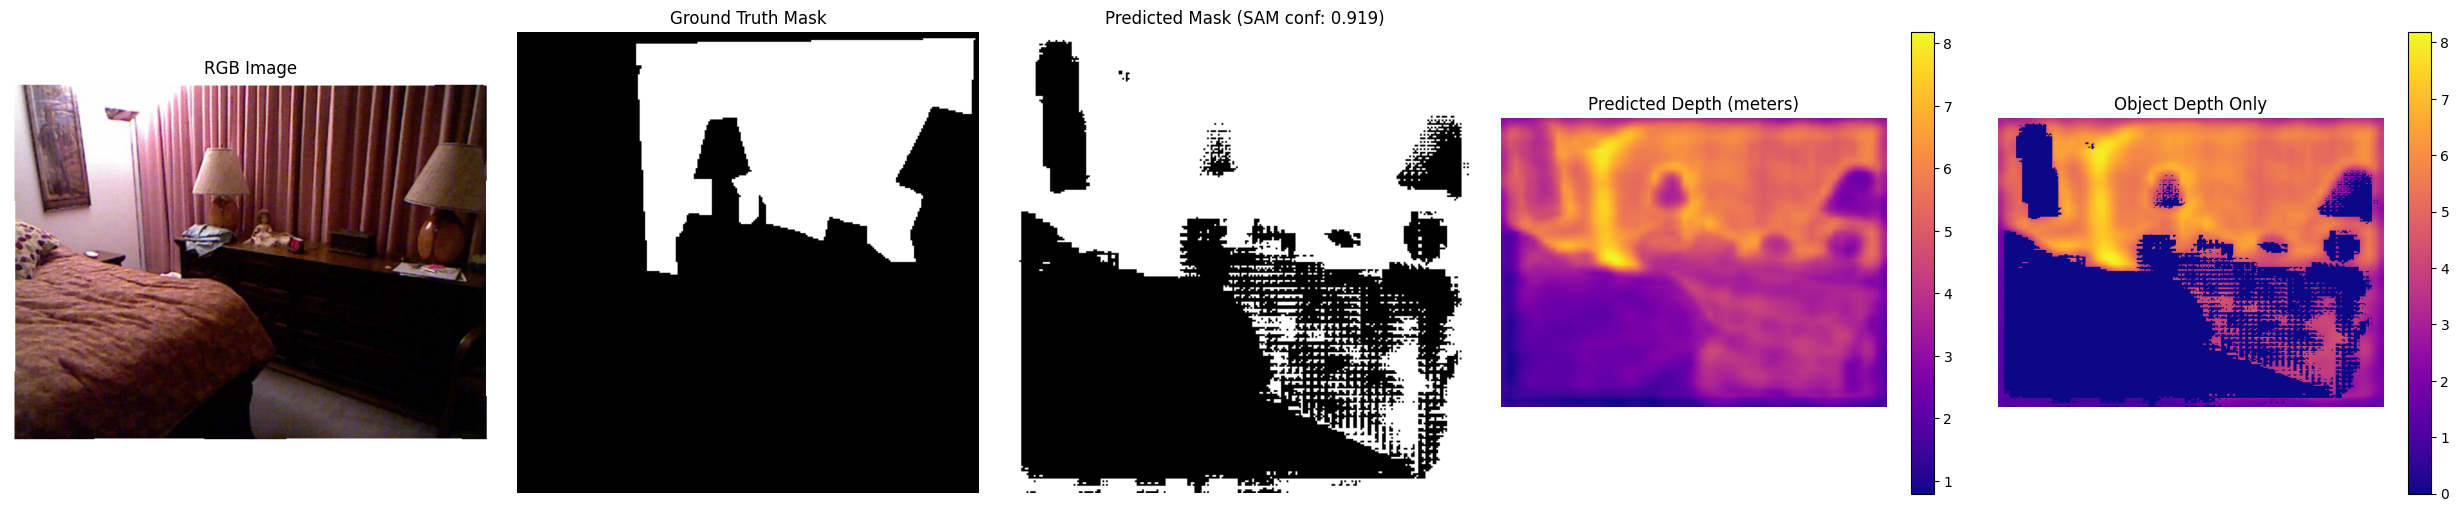


Running instance segmentation...


C:\Users\ACER\AppData\Local\Temp\ipykernel_13240\838574753.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab20', max(n, 1))


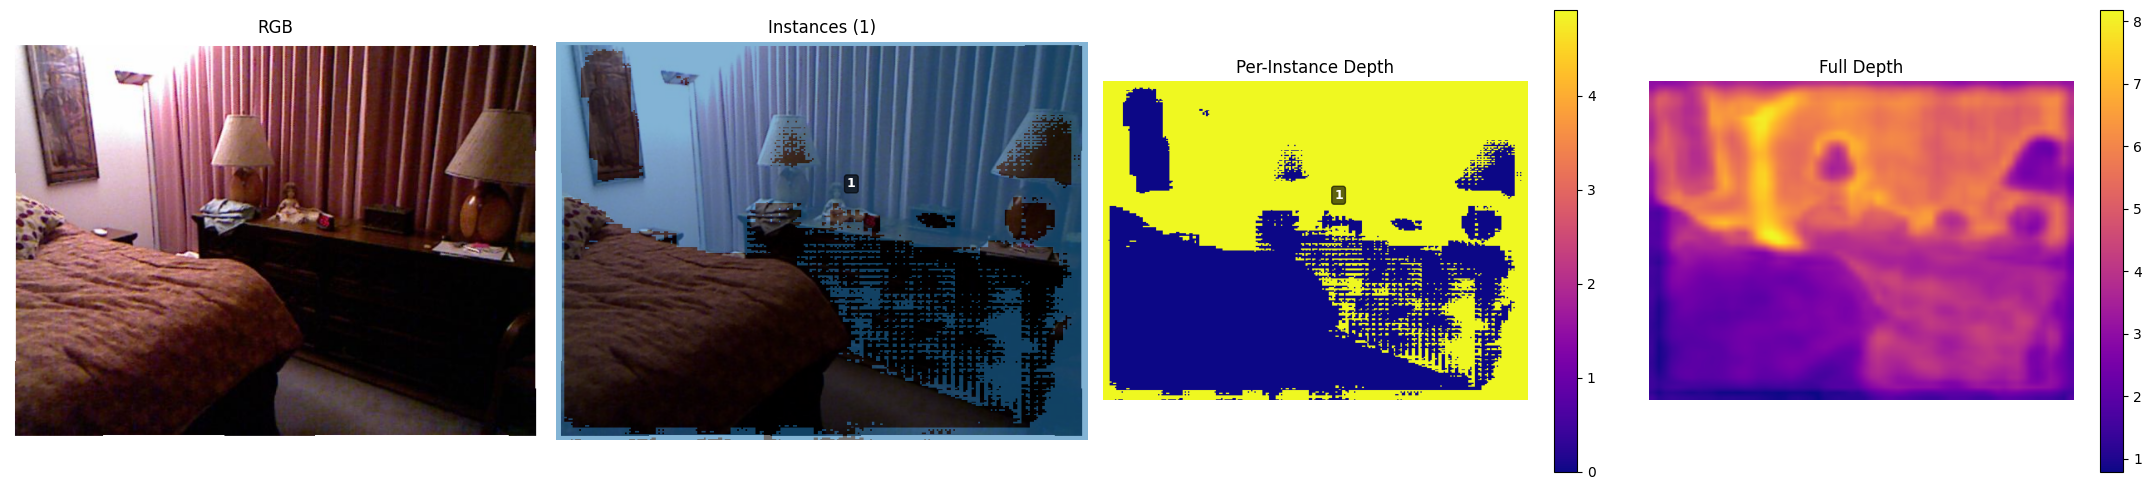


1 instances (from 144 candidates):
   1: depth=4.91m  score=0.931  px=167347


In [11]:
BEST_CKPT = 'D:/Projects/Minor Project/Parameters/Fusion-Checkpoints/best_model_20.pth'
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
fusion_model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

fusion_model.eval()
sample_no = 15

# load a sample NYU image directly from .mat
import h5py
MAT_PATH = 'D:/Projects/Minor Project/Datasets/raw/NYU depth v2/nyu_depth_v2_labeled.mat'
with h5py.File(MAT_PATH, 'r') as f:
    total     = f['images'].shape[0]
    split_idx = int(total * 0.8)
    val_indices = list(range(split_idx, total))
    img_raw   = np.transpose(np.array(f['images'][val_indices[sample_no]]), (2, 1, 0))   # (480,640,3)
    depth_raw = np.transpose(np.array(f['depths'][val_indices[sample_no]]), (1, 0))      # (480,640)
    label_raw = np.transpose(np.array(f['labels'][val_indices[sample_no]]), (1, 0))      # (480,640)

img_np = img_raw  # RGB (480,640,3)

# gt mask - largest object
u, c = np.unique(label_raw, return_counts=True)
mask = u > 0
u, c = u[mask], c[mask]
chosen = u[np.argmax(c)]
binary_mask = (label_raw == chosen).astype(np.float32)
mask_256    = cv2.resize(binary_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
gt_mask     = torch.from_numpy(mask_256).unsqueeze(0)  # [1,256,256]

# compute features on the fly
img_bgr  = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
img_1024 = cv2.resize(img_np, (1024, 1024))
sam_inp  = torch.from_numpy(img_1024).permute(2,0,1).float()/255.0
sam_inp  = sam_inp.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    sam_feat   = fusion_model.sam.image_encoder(sam_inp)
    depth_feat = get_depth_encoder_features(fusion_model.depth_model, img_bgr).to(DEVICE)

    _, _, pred_depth = fusion_model(sam_feat, depth_feat)

    depth_small    = F.interpolate(pred_depth, size=(256, 256), mode='bilinear', align_corners=False)
    depth_np_small = depth_small.squeeze().cpu().numpy()
    y, x = np.unravel_index(depth_np_small.argmin(), depth_np_small.shape)
    point_coords = torch.tensor([[[x, y]]], dtype=torch.float32).to(DEVICE)
    point_labels = torch.tensor([[1]], dtype=torch.int).to(DEVICE)

    low_res_masks, iou_pred, pred_depth = fusion_model(sam_feat, depth_feat, point_coords, point_labels)

pred_mask = (torch.sigmoid(low_res_masks) > 0.3).float().squeeze().cpu().numpy()

# resize depth to 480x640 for visualization
depth_vis     = F.interpolate(pred_depth, size=(480, 640), mode='bilinear', align_corners=False)
depth_np_full = depth_vis.squeeze().cpu().numpy()

mask_full    = F.interpolate(
    (torch.sigmoid(low_res_masks) > 0.3).float(),
    size=(480, 640), mode='nearest'
).squeeze().cpu().numpy()
object_depth = depth_np_full * mask_full

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(img_np)
axes[0].set_title('RGB Image')
axes[0].axis('off')

axes[1].imshow(gt_mask.squeeze().numpy(), cmap='gray')
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(pred_mask, cmap='gray')
axes[2].set_title(f'Predicted Mask (SAM conf: {iou_pred.item():.3f})')
axes[2].axis('off')

axes[3].imshow(depth_np_full, cmap='plasma')
axes[3].set_title('Predicted Depth (meters)')
axes[3].axis('off')
plt.colorbar(axes[3].images[0], ax=axes[3])

axes[4].imshow(object_depth, cmap='plasma')
axes[4].set_title('Object Depth Only')
axes[4].axis('off')
plt.colorbar(axes[4].images[0], ax=axes[4])

plt.tight_layout()
plt.show()

print("\nRunning instance segmentation...")
instance_map, instance_depths = get_instance_segmentation(
    fusion_model, img_np, DEVICE, grid_size=12, iou_threshold=0.88, score_threshold=0.3)


In [4]:
import h5py
import numpy as np

f = h5py.File('D:/Projects/Minor Project/Datasets/raw/NYU depth v2/nyu_depth_v2_labeled.mat', 'r')

images    = f['images']     # RGB
depths    = f['depths']     # depth
instances = f['instances']  # instance masks

print(f"images shape:    {images.shape}")
print(f"depths shape:    {depths.shape}")
print(f"instances shape: {instances.shape}")

# check one sample
inst0 = np.array(instances[0])
u, c  = np.unique(inst0, return_counts=True)
u, c  = u[u > 0], c[u > 0]
total = inst0.shape[0] * inst0.shape[1]
print(f"\nSample 0: {len(u)} instances")
for uid, cnt in zip(u, c):
    print(f"  id={uid}: coverage={cnt/total:.3f}")

images shape:    (1449, 3, 640, 480)
depths shape:    (1449, 640, 480)
instances shape: (1449, 640, 480)

Sample 0: 5 instances
  id=1: coverage=0.310
  id=2: coverage=0.249
  id=3: coverage=0.006
  id=4: coverage=0.321
  id=5: coverage=0.042


In [11]:
import h5py
import numpy as np
import torch
import cv2
from torch.utils.data import Dataset

class NYUDepthDataset(Dataset):
    def __init__(self, mat_path, max_samples=None):
        f = h5py.File(mat_path, 'r')
        self.images    = f['images']     # (1449, 3, 640, 480)
        self.depths    = f['depths']     # (1449, 640, 480)
        self.instances = f['instances']  # (1449, 640, 480)
        self.n = len(self.images) if max_samples is None else min(max_samples, len(self.images))

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        # images are (3, 640, 480) — transpose to (480, 640, 3)
        img = np.array(self.images[idx]).transpose(2, 1, 0).astype(np.uint8)  # (480, 640, 3)

        # depth — transpose to (480, 640)
        depth = np.array(self.depths[idx]).T.astype(np.float32)  # (480, 640)
        depth = np.clip(depth, 0, 10.0)
        gt_depth = torch.from_numpy(depth).unsqueeze(0)  # (1, 480, 640)

        # instance mask — transpose to (480, 640)
        inst = np.array(self.instances[idx]).T.astype(np.int32)  # (480, 640)
        print(inst.shape)

        u, c = np.unique(inst, return_counts=True)
        u, c = u[u > 0], c[u > 0]
        total = inst.shape[0] * inst.shape[1]

        # pick furniture-sized object (0.01 < coverage < 0.30)
        chosen_class = None
        for i in np.argsort(c)[::-1]:
            candidate = (inst == u[i]).astype(np.float32)
            cov = candidate.mean()
            if 0.01 < cov < 0.30:
                chosen_class = u[i]
                break

        if chosen_class is None:
            for i in np.argsort(c)[::-1]:
                if (inst == u[i]).astype(np.float32).mean() < 0.40:
                    chosen_class = u[i]
                    break

        if chosen_class is None:
            chosen_class = u[np.argmax(c)]

        binary_mask = (inst == chosen_class).astype(np.float32)
        mask_256    = cv2.resize(binary_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        gt_mask     = torch.from_numpy(mask_256).unsqueeze(0)

        return {'gt_mask': gt_mask, 'gt_depth': gt_depth, 'index': idx, 'img': img}

(480, 640)
img shape:   (480, 640, 3)
depth range: 1.80 - 3.62
mask coverage: 0.249


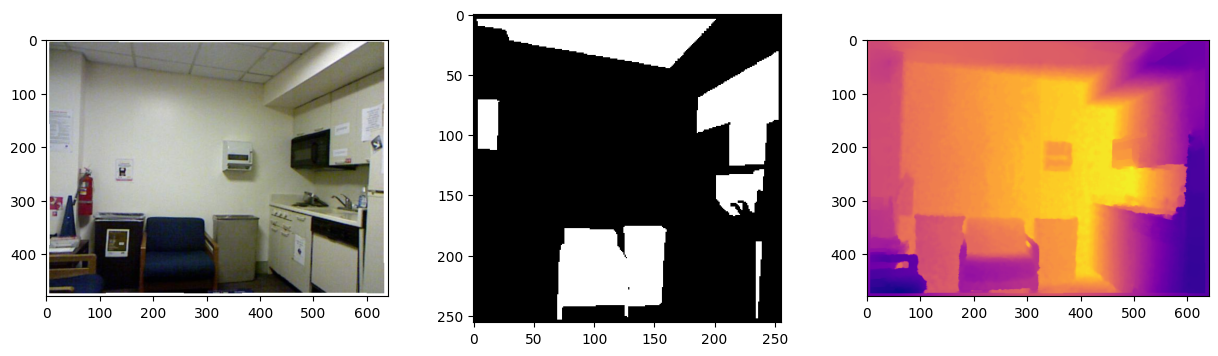

In [12]:
# test locally
mat_path = 'D:/Projects/Minor Project/Datasets/raw/NYU depth v2/nyu_depth_v2_labeled.mat'
ds = NYUDepthDataset(mat_path)
sample = ds[0]
print(f"img shape:   {sample['img'].shape}")       # should be (480, 640, 3)
print(f"depth range: {sample['gt_depth'].min():.2f} - {sample['gt_depth'].max():.2f}")
print(f"mask coverage: {sample['gt_mask'].mean():.3f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(sample['img'])
axes[1].imshow(sample['gt_mask'].squeeze(), cmap='gray')
axes[2].imshow(sample['gt_depth'].squeeze(), cmap='plasma')
plt.show()